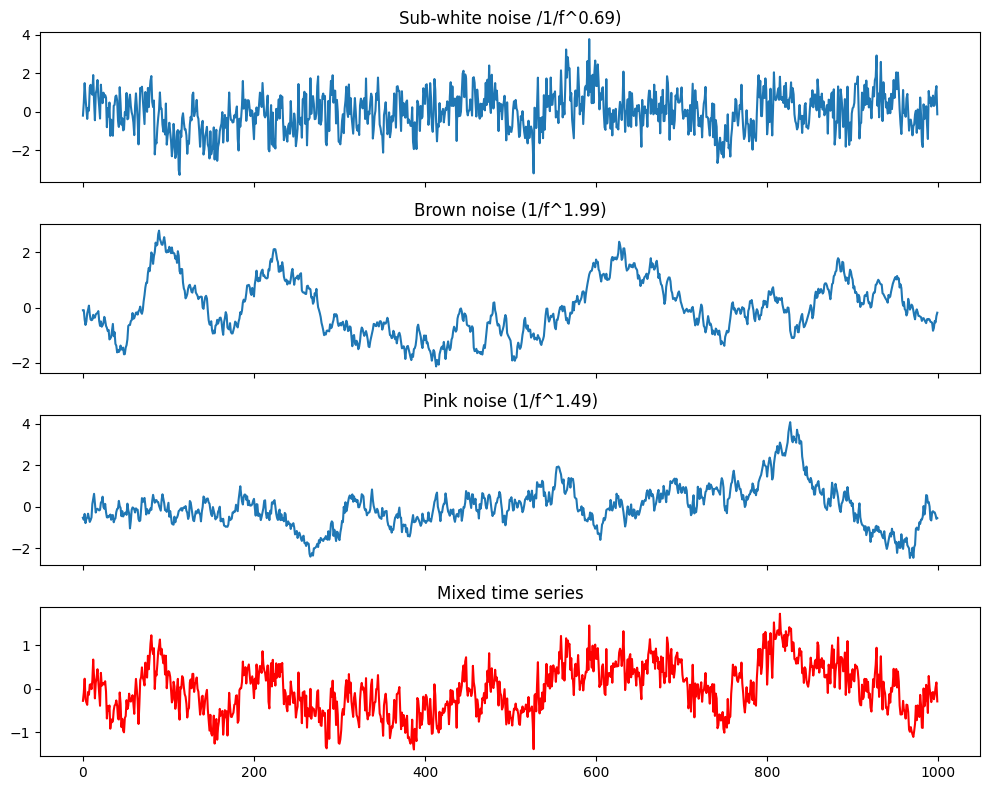

In [ ]:
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt

def gen_beta_noise(n, beta):
    """
    Generates 1/f^beta noise using the algorithm from
    Timmer, J. and Koenig, M.: On Generating Power Law Noise. A&A 300, 707-710 (1995)
    """
    # Generate white noise
    white_noise = np.random.randn(n)

    # Compute Fourier frequencies
    frequencies = np.fft.fftfreq(n)
    frequencies[0] = 1e-6

    # Compute the scaling factor for each frequency
    scaling = np.power(np.abs(frequencies), -beta/2)

    # Compute the Fourier transform of the noise
    fft_noise = np.fft.fft(white_noise)

    # Multiply the Fourier transform by the scaling factor
    fft_beta_noise = scaling * fft_noise

    # Compute the inverse Fourier transform to obtain the noise in the time domain
    beta_noise = np.real(np.fft.ifft(fft_beta_noise))

    return beta_noise

def gen_mixed_time_series(n, beta, p=0.5):
    """
    Generates a mixed time series with 1/f^beta noise and a random walk with probability p
    """
    # Generate 1/f^beta noise
    noise = gen_beta_noise(n, beta)

    # Generate random walk
    random_walk = np.cumsum(np.random.randn(n))

    # Combine noise and random walk with probability p
    mixed_ts = np.where(np.random.rand(n) < p, random_walk, noise)

    return mixed_ts

# Parameters
n = 1000
beta = 1.49

# Generate different types of time series
white_noise = gen_beta_noise(n, 0.69); white_noise = (white_noise-np.mean(white_noise))/np.std(white_noise)
pink_noise = gen_beta_noise(n, beta); pink_noise = (pink_noise-np.mean(pink_noise))/np.std(pink_noise)
brown_noise = gen_beta_noise(n, 1.99); brown_noise = (brown_noise-np.mean(brown_noise))/np.std(brown_noise)
#mixed_ts = gen_mixed_time_series(n, beta)
mixed_ts = (white_noise+pink_noise+brown_noise)/3

# Plot time series
fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axs[0].plot(white_noise)
axs[0].set_title("Sub-white noise /1/f^{})".format(0.69))

axs[1].plot(brown_noise)
axs[1].set_title("Brown noise (1/f^{})".format(1.99))

axs[2].plot(pink_noise)
axs[2].set_title("Pink noise (1/f^{})".format(beta))

axs[3].plot(mixed_ts, 'r')
axs[3].set_title("Mixed time series")

plt.tight_layout()
plt.show()


In [ ]:
!pip install colorednoise

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


[[0.98970077 1.07620139 0.94869212 1.06943823 0.97938554]
 [0.99220816 1.12743243 0.98449482 1.07028484 1.03444961]
 [0.92295442 0.95165135 0.96136637 1.03332632 1.06751171]
 [0.97644587 1.2068472  0.94516001 1.02386987 0.86943645]
 [0.9594103  1.01580695 1.27319761 1.12904729 1.05065483]
 [1.20363794 0.93041788 1.00958034 0.94452447 1.07576031]
 [1.03777956 0.91230481 0.86230321 0.95398216 1.20983556]
 [1.00281646 0.90642764 1.03966793 0.88361827 0.84482348]
 [0.97930846 1.00137353 0.9546531  1.02240883 1.04910508]
 [1.03500757 1.12245583 0.99555407 1.09834786 1.10799764]]


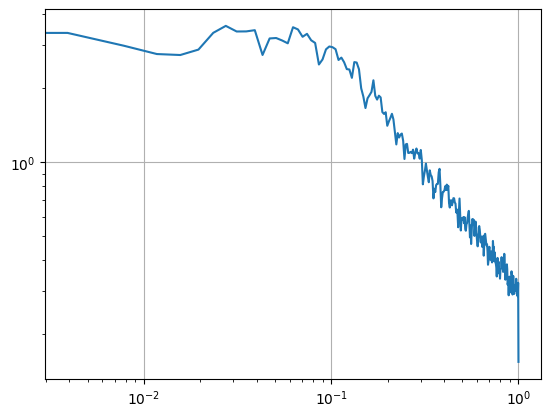

In [ ]:
import colorednoise as cn
from matplotlib import mlab
beta = 1 # the exponent
samples = 2**18 # number of samples to generate
y = cn.powerlaw_psd_gaussian(beta, samples)

# optionally plot the Power Spectral Density with Matplotlib
#from matplotlib import mlab
#from matplotlib import pylab as plt
#s, f = mlab.psd(y, NFFT=2**13)
#plt.loglog(f,s)
#plt.grid(True)
#plt.show()
# generate several time series of independent indentically distributed variables
# repeat the simulation of each variable multiple times
import colorednoise as cn
n_repeats   = 10   # repeat simulatons
n_variables = 5    # independent variables in each simulation
timesteps   = 1000 # number of timesteps for each variable
y = cn.powerlaw_psd_gaussian(1, (n_repeats, n_variables, timesteps))

# the expected variance of for each variable is 1, but each realisation is different
print(y.std(axis=-1))
# generate a broken power law spectrum: white below a frequency of

#import colorednoise as cn
y = cn.powerlaw_psd_gaussian(1, 10**5, fmin=.05)
s, f = mlab.psd(y, NFFT=2**9)
plt.loglog(f,s)
plt.grid(True)
plt.show()

In [ ]:
!pip install hmmlearn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 2.4 MB/s eta 0:00:00


In [ ]:
###X
from hmmlearn import hmm
latent_data = pink_noise.reshape(-1, 1)

# generate samples continuously
_, Z = hmm.GaussianHMM (latent_data, n_samples=10)
X, Z = model.sample(n_samples=10, currstate=Z[-1])

TypeError: ignored

In [ ]:
from hmmlearn import hmm
latent_data = pink_noise.reshape(-1, 1)

# generate samples continuously
hmm.GaussianHMM (latent_data)
hmm_model.sample(n_samples=10, currstate=Z[-1])

NameError: ignored

In [ ]:
# Define the number of hidden states
n_components = 3

# Initialize the HMM with random parameters
hmm_model = hmm.GaussianHMM(n_components=n_components, n_iter=100, init_params="mcs", covariance_type='full')

# Train the HMM using the Baum-Welch algorithm
hmm_model.fit(latent_data)

NameError: ignored

In [ ]:
!pip install keras

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
x = brown_noise
m = 2
r = .2

import numpy as np
import matplotlib.pyplot as plt
from keras.models import Model
from keras.layers import Input, Dense

def sampen(x, m, r):
    """
    Calculate the sample entropy of a time series x, given m and r
    """
    N = len(x)
    B = np.zeros((N-m+1, m))
    for i in range(N-m+1):
        B[i,:] = x[i:i+m]
    Cm = np.zeros((N-m+1,N-m+1))
    for i in range(N-m+1):
        for j in range(i,N-m+1):
            Cm[i,j] = max(np.abs(B[i,:]-B[j,:]))
            Cm[j,i] = Cm[i,j]
    Am = (Cm <= r)
    Cm = np.sum(Am,axis=0)
    phi = np.sum(np.log(Cm))/(N-m+1)
    return -phi

def corr_int(x, rmax):
    """
    Calculate the correlation integral of a time series x, given rmax
    """
    N = len(x)
    dist_mat = np.abs(np.subtract.outer(x, x))
    C = np.sum(dist_mat <= rmax)
    C = C - N
    return C


print(f'Correlation Integral: {corr_int (x, r)}', end='\n')
print(f'Sample Entropy: {sampen(x,m,r)}')

Correlation Integral: 122484
Sample Entropy: -4.44326201696849


In [ ]:
a = 2
b = "Datacamp"
print("%d is an integer while %s is a string."%(a,b))

print('%.3f' % 3.14159)          # Prints 3.142

2 is an integer while Datacamp is a string.
3.142


In [ ]:
def create_tuple(*args):
    my_list = []
    for arg in args:
        my_list.append(arg * 10)
    return tuple(my_list)


t = create_tuple(1, 2, 3)
print(f'Tuple returned by create_tuple(1,2,3) is {t}')

Tuple returned by create_tuple(1,2,3) is (10, 20, 30)


In [ ]:
import time

def my_timer(func):
     def _timer(*args, **kwargs):
         start = time.time()
         result = func(*args, **kwargs)
         end = time.time()
         print(f"Execution time: {end - start}")
         return result
     return _timer


In [ ]:
@my_timer
def delayed_mean(sample):
     time.sleep(1.001)
     return sum(sample) / len(sample)

delayed_mean([10, 5, 1])

Execution time: 1.0019543170928955


5.333333333333333

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Model
from keras.layers import Input, Dense

def sampen(x, m, r):
    """
    Calculate the sample entropy of a time series x, given m and r
    """
    N = len(x)
    B = np.zeros((N-m+1, m))
    for i in range(N-m+1):
        B[i,:] = x[i:i+m]
    Cm = np.zeros((N-m+1,N-m+1))
    for i in range(N-m+1):
        for j in range(i,N-m+1):
            Cm[i,j] = max(np.abs(B[i,:]-B[j,:]))
            Cm[j,i] = Cm[i,j]
    Am = (Cm <= r)
    Cm = np.sum(Am,axis=0)
    phi = np.sum(np.log(Cm))/(N-m+1)
    return -phi

def corr_int(x, rmax):
    """
    Calculate the correlation integral of a time series x, given rmax
    """
    N = len(x)
    dist_mat = np.abs(np.subtract.outer(x, x))
    C = np.sum(dist_mat <= rmax)
    C = C - N
    return C

def create_autoencoder(input_dim, encoding_dim):
    """
    Create an autoencoder-like architecture for encoding r and m computation steps
    """
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation='relu')(input_layer)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dense(16, activation='relu')(encoded)
    encoded_r = Dense(encoding_dim, activation='linear', name='encoded_r')(encoded)
    encoded_m = Dense(encoding_dim, activation='linear', name='encoded_m')(encoded)
    decoded = Dense(16, activation='relu')(encoded)
    decoded = Dense(32, activation='relu')(decoded)
    decoded = Dense(64, activation='relu')(decoded)
    decoded = Dense(input_dim, activation='linear')(decoded)
    autoencoder = Model(input_layer, [decoded, encoded_r, encoded_m])
    autoencoder.compile(optimizer='adam', loss=['mse', 'mse', 'mse'])
    return autoencoder

# Generate a test time series
t = np.linspace(0, 10*np.pi, 1000)
x = np.sin(t) + np.random.normal(0, 0.1, 1000)

# Define the parameters
m = 1
r = 0.5
rmax = 0.5

# Train the autoencoder
input_dim = 1000
encoding_dim = 10
autoencoder = create_autoencoder(input_dim, encoding_dim)
autoencoder.fit(x.reshape(-1, input_dim), [x.reshape(-1, input_dim), np.zeros((len(x), encoding_dim)), np.zeros((len(x), encoding_dim))], epochs=100)

# Use the layers to calculate the Correlation Integral and Sample Entropy
encoded_output = autoencoder.predict(x.reshape(-1, input_dim))[1:]
r_layer_output = encoded_output[0]
m_layer_output = encoded_output[1]
C = corr_int(r_layer_output, rmax)
SampEn = sampen(m_layer_output[:,0], m, r)

print(f"Correlation Integral: {C}")
print(f"Sample Entropy: {SampEn}")

ValueError: ignored